<a href="https://colab.research.google.com/github/K26almulla/Comparison-Glove-VS-word2vec/blob/main/NLPA_lab4b_sentiment_CNN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Install dependencies
!pip install -q keras gensim spacy
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Step 2: Load TSV file from Google Drive

from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Put your file path here
file_path = '/content/drive/MyDrive/NLP2/week4/imdb_labelled (1) (1).tsv'

# Read TSV file
df = pd.read_csv(
    file_path,
    sep='\t',
    header=None,
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip'
)

# Rename columns
df.columns = ['Text', 'Label']

# Show first rows
print(df.head())

Mounted at /content/drive
                                                Text  Label
0  A very, very, very slow-moving, aimless movie ...      0
1  Not sure who was more lost - the flat characte...      0
2  Attempting artiness with black & white and cle...      0
3       Very little music or anything to speak of.        0
4  The best scene in the movie was when Gerardo i...      1


In [3]:
# STEP 3: Preprocessing using SpaCy
import spacy
nlp = spacy.load("en_core_web_sm")

def spacy_tokenize(text):
    doc = nlp(text)
    return [token.text.lower() for token in doc if not token.is_punct and not token.is_stop]

df['tokens'] = df['Text'].apply(spacy_tokenize)
df['Text_Final'] = [' '.join(toks) for toks in df['tokens']]
df['Pos'] = df['Label']
df['Neg'] = 1 - df['Label']
df.head()

,Text,Label,tokens,Text_Final,Pos,Neg
0,"A very, very, very slow-moving, aimless movie ...",0,"[slow, moving, aimless, movie, distressed, dri...",slow moving aimless movie distressed drifting ...,0,1
1,Not sure who was more lost - the flat characte...,0,"[sure, lost, flat, characters, audience, nearl...",sure lost flat characters audience nearly half...,0,1
2,Attempting artiness with black & white and cle...,0,"[attempting, artiness, black, white, clever, c...",attempting artiness black white clever camera ...,0,1
3,Very little music or anything to speak of.,0,"[little, music, speak, ]",little music speak,0,1
4,The best scene in the movie was when Gerardo i...,1,"[best, scene, movie, gerardo, trying, find, so...",best scene movie gerardo trying find song keep...,1,0


In [4]:
# STEP 4: Train-test split
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(df, test_size=0.1, random_state=42)
MAX_SEQUENCE_LENGTH = 50

In [5]:
#  STEP 5: Choose embedding model
embedding_choice = input("Choose embedding model ('word2vec' or 'glove'): ").strip().lower()

Choose embedding model ('word2vec' or 'glove'): word2vec


In [6]:
# STEP 6: Load Word2Vec or GloVe from Google Drive (no need to upload manually!)
import numpy as np
from gensim.models import KeyedVectors
from google.colab import drive

# Mount Google Drive
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

embedding_choice = embedding_choice.strip().lower()

if embedding_choice == "word2vec":
    # ✅ CHANGE THIS to your actual path in Google Drive
    word2vec_path = "/content/drive/MyDrive/NLP2/week4/GoogleNews-vectors-negative300.bin"

    print(f"📥 Loading Word2Vec model from: {word2vec_path}")
    word_vectors = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
    EMBEDDING_DIM = 300

elif embedding_choice == "glove":
    # ✅ CHANGE THIS to your actual GloVe file path in Drive
    glove_path = "/content/drive/MyDrive/BUiD documents/Applied Natural - documents/Lab 4/glove.6B.100d.txt"

    # Automatically detect dimensionality from filename
    if "50d" in glove_path:
        EMBEDDING_DIM = 50
    elif "100d" in glove_path:
        EMBEDDING_DIM = 100
    elif "200d" in glove_path:
        EMBEDDING_DIM = 200
    elif "300d" in glove_path:
        EMBEDDING_DIM = 300
    else:
        raise ValueError("❌ Couldn't detect embedding size from filename")

    print(f"📥 Loading GloVe model from: {glove_path}")
    glove_dict = {}
    with open(glove_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_dict[word] = vector

    class DictVectorWrapper:
        def __contains__(self, key): return key in glove_dict
        def __getitem__(self, key): return glove_dict[key]

    word_vectors = DictVectorWrapper()

else:
    raise ValueError("❌ Invalid choice. Choose 'word2vec' or 'glove'")


📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading Word2Vec model from: /content/drive/MyDrive/NLP2/week4/GoogleNews-vectors-negative300.bin


Next step : Tokenize the text: converting each word into an integer based on frequency.

Then, convert each sentence into a list of integers (one per word).

Finally, pad all sequences so they’re the same length (important for input into a neural network).

In [7]:
# STEP 7: text tokenization and padding sequences

# Import tools for text tokenization and padding sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Create a tokenizer instance that will convert words to unique integers
tokenizer = Tokenizer()

# Fit the tokenizer on the training text data (learn vocabulary and assign integer indices)
tokenizer.fit_on_texts(data_train['Text_Final'].tolist())

# Convert the training text into sequences of integers (word → index)
train_sequences = tokenizer.texts_to_sequences(data_train['Text_Final'].tolist())

# Do the same for the test data
test_sequences = tokenizer.texts_to_sequences(data_test['Text_Final'].tolist())

# Retrieve the dictionary mapping words to their integer indices
word_index = tokenizer.word_index

# Pad/truncate the training sequences to a uniform length (MAX_SEQUENCE_LENGTH)
train_data = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Apply the same padding/truncating to test sequences
test_data = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH)


example:

texts = ["I love cats", "Cats are amazing"]

You tokenize them:

{'cats': 1, 'i': 2, 'love': 3, 'are': 4, 'amazing': 5}

Resulting data:

[[0, 0, 2, 3, 1],   # "I love cats"

[0, 0, 1, 4, 5]]   # "Cats are amazing"

In [8]:
# Step 8 : Create an embedding matrix to map each word index to its corresponding vector
embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))

# Loop through each word and its corresponding index in the tokenizer's vocabulary
for word, i in word_index.items():

    # Check if the word has a pre-trained embedding vector (e.g., from GloVe or Word2Vec)
    if word in word_vectors:
        # If yes, assign it to the corresponding row in the embedding matrix
        embedding_matrix[i] = word_vectors[word]
    else:
        # If not, initialize it with a random vector (so the model can learn it during training)
        embedding_matrix[i] = np.random.randn(EMBEDDING_DIM)

**example:**

texts = ["I love cats", "Cats are amazing"]

**You tokenize them:**

{'cats': 1, 'i': 2, 'love': 3, 'are': 4, 'amazing': 5}

**Let’s say we use 3D embeddings for illustration (real GloVe is 50–300D):**

word_vectors = {

    "i":       np.array([0.1, 0.2, 0.3]),
    "love":    np.array([0.4, 0.5, 0.6]),
    "cats":    np.array([0.7, 0.8, 0.9]),
    "are":     np.array([0.1, 0.0, 0.1]),
    # "amazing" is missing in GloVe (for the example purpose)
}
EMBEDDING_DIM = 3

**Index	Word	Vector**

0	padding	[0.0, 0.0, 0.0]

1	cats	[0.7, 0.8, 0.9]

2	i	[0.1, 0.2, 0.3]

3	love	[0.4, 0.5, 0.6]

4	are	[0.1, 0.0, 0.1]

5	amazing	[1.1, -0.2, 0.3] (random)

**Then, if the input sequence is:**
[0, 0, 2, 3, 1] # "I love cats"

**It becomes:**

[
 [0.0, 0.0, 0.0],     # padding

 [0.0, 0.0, 0.0],     # padding

 [0.1, 0.2, 0.3],     # 'i'

 [0.4, 0.5, 0.6],     # 'love'

 [0.7, 0.8, 0.9]      # 'cats'

]


In [9]:
# Step 9: Build a Convolutional Neural Network (CNN) to classify text sequences using pre-trained word embeddings.

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dropout, Dense

# Create an embedding layer using pre-trained GloVe vectors
embedding_layer = Embedding(
    input_dim=len(word_index) + 1,    # Total vocabulary size (+1 for padding index 0)
    output_dim=EMBEDDING_DIM,         # Size of each embedding vector (e.g., 100)
    weights=[embedding_matrix],       # Use the preloaded embedding matrix
    input_length=MAX_SEQUENCE_LENGTH, # Input sequence length (same used in pad_sequences)
    trainable=False                   # Keep embeddings fixed (do not update during training)
)

# Define the model input: a sequence of word indices
sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')

# Apply the embedding layer to convert word indices to dense vectors
x = embedding_layer(sequence_input)

# First 1D convolutional layer with 200 filters and kernel size 2
x = Conv1D(200, 2, activation='relu')(x)

# Max pooling layer to reduce sequence length and retain key features
x = MaxPooling1D()(x)

# Second 1D convolutional layer with 200 filters and kernel size 3
x = Conv1D(200, 3, activation='relu')(x)

# Another max pooling layer
x = MaxPooling1D()(x)

# Flatten the 3D tensor to a 1D vector for input into Dense layers
x = Flatten()(x)

# Dropout layer to reduce overfitting (randomly drop 10% of the neurons)
x = Dropout(0.1)(x)

# Dense (fully connected) layer with 128 neurons and ReLU activation
x = Dense(128, activation='relu')(x)

# Another dropout layer
x = Dropout(0.1)(x)

# Output layer with 2 neurons (for binary classification) and sigmoid activation
output = Dense(2, activation='sigmoid')(x)

# Define the model using the functional API
model = Model(sequence_input, output)

# Compile the model with Adam optimizer and binary crossentropy loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model architecture summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 300)        │       665,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 49, 200)        │       120,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 200)        │       120,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       281,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,187,786 (4.53 MB)

 Trainable params: 522,386 (1.99 MB)

 Non-trainable params: 665,400 (2.54 MB)

The model starts with:

A sequence of 50 word indices → turns into (50, 300) word vectors

Passes through conv/pool layers → shrinks to (11, 200)

Flattened → Dense → Output

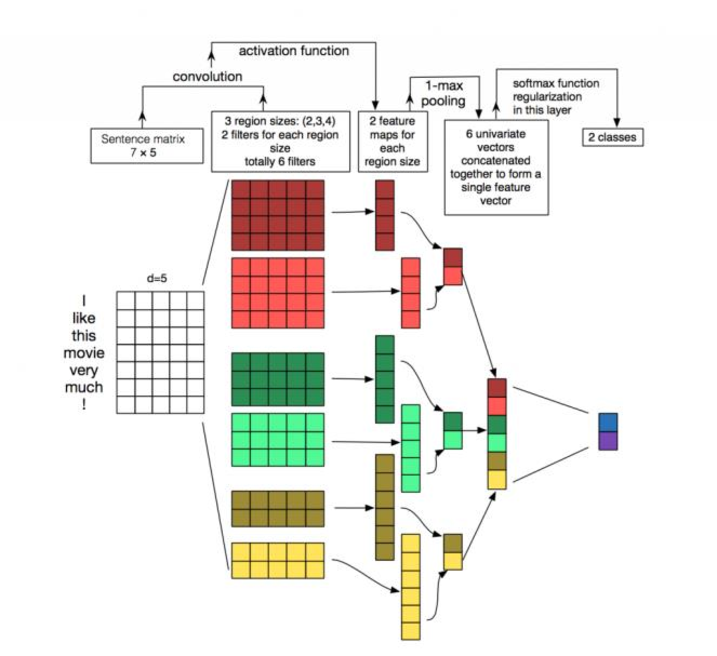

In [10]:
# Step 10 : Model Training

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Prepare the target labels in one-hot encoded format
# y_train and y_test will be arrays of shape (samples, 2) for binary classification
y_train = data_train[['Pos', 'Neg']].values
y_test = data_test[['Pos', 'Neg']].values

# Define EarlyStopping callback:
# Stop training if the validation loss doesn't improve for 5 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',  # What metric to monitor
    patience=5,          # Number of epochs to wait before stopping
    verbose=1            # Print message when stopping
)

# Define ModelCheckpoint callback:
# Save the model only when it achieves a lower validation loss than previous best
checkpoint = ModelCheckpoint(
    'best_CNN_model.keras',  # Filepath to save the best model
    monitor='val_loss',      # What metric to monitor
    save_best_only=True      # Only save if the model is better than before
)

# Train the model
history = model.fit(
    train_data,              # Padded training sequences
    y_train,                 # Corresponding labels (2-column one-hot)
    epochs=20,               # Maximum number of training epochs
    batch_size=32,           # Number of samples per training batch
    validation_split=0.1,    # Use 10% of training data for validation
    callbacks=[early_stop, checkpoint]  # Apply early stopping and checkpointing
)


Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5641 - loss: 0.6838 - val_accuracy: 0.5224 - val_loss: 0.6842
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7371 - loss: 0.6050 - val_accuracy: 0.6418 - val_loss: 0.6387
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8636 - loss: 0.3926 - val_accuracy: 0.6716 - val_loss: 0.6890
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9085 - loss: 0.2283 - val_accuracy: 0.6418 - val_loss: 0.9887
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9368 - loss: 0.1587 - val_accuracy: 0.6716 - val_loss: 1.1432
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9601 - loss: 0.1099 - val_accuracy: 0.6716 - val_loss: 1.2427
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9700 - loss: 0.1007 - val_accuracy: 0.6716 - val_loss: 1.2927
Epoch 7: early stopping


**example:**

Pos = 1 if it's a positive sentence

Neg = 1 if it's a negative sentence

y_train = np.array([

    [1, 0],  # "I love cats"
    [0, 1],  # "Cats are annoying"
    [1, 0],  # "Amazing performance"
    [0, 1]   # "Very bad movie"
])

In [11]:
from tensorflow.keras.models import load_model

model = load_model('best_CNN_model.keras')
results = model.evaluate(test_data, y_test, verbose=1)
print(f"📊 Test Accuracy: {results[1]*100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7600 - loss: 0.5769 
📊 Test Accuracy: 76.00%


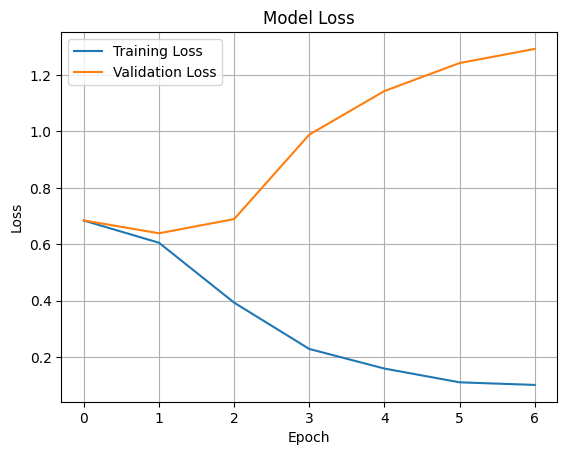

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


If both lines go down: your model is learning well.

If validation loss goes up while training loss goes down: overfitting.

If they are both flat: model is underfitting or learning too slowly.

**Bonus: Sentiment Analysis Web App (CNN)**

Build a simple web app for sentiment analysis using the CNN model from the lab, improve it, and test it on another dataset.

**What You Need to Do:**
1. Build a Web App (Streamlit)- Your app should :
* Take a sentence as input
* Predict sentiment (Positive / Negative)
* Show confidence score
* Allow CSV upload (multiple texts)

2. Use the CNN from the Lab (Reuse the same pipeline)

3. Improve the Model- Make at least one meaningful change, such as:

* add/remove Conv1D layers
* change number of filters
* add dropout
* change embedding settings
* modify sequence length

❗ Small changes (like only epochs) are NOT enough

4. Compare Models- Original CNN (lab) vs Your improved CNN

* accuracy
* loss
* which one is better

5. Use Another Dataset - Test your model on a different dataset (e.g., tweets, product reviews) : Does performance change? why?

In [13]:
%cd /content/drive/MyDrive/NLP2/week4

/content/drive/MyDrive/NLP2/week4


In [14]:
!pip install tensorflow streamlit pandas numpy scikit-learn pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.9 MB/s eta 0:00:00


In [15]:
!streamlit run app.py &>/content/logs.txt &


In [16]:
from pyngrok import ngrok

ngrok.set_auth_token("2tomBYRCyEO8TKZhIfjdDZ7LinT_2HfKfRTYdmVWXchB5fQY8")

In [17]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://700c-35-231-93-229.ngrok-free.app" -> "http://localhost:8501"
